In [1]:

import sys
if 'google.colab' in sys.modules:
    !pip install utdquake

lib = None
lib = "/home/edc240000/UTDQuake"
if lib is not None:
    sys.path.append(lib)

# Version (Required)

In [ ]:
import utdquake
from packaging.version import Version

current_version = Version(utdquake.__version__)
required_version = Version("0.0.21")

if current_version < required_version:
    raise Exception(f"Please update utdquake to at least version {required_version}")

# UTDClient

## get custom stations

In [32]:
from utdquake.clients.fdsn.client import Client

provider = "texnet"
out = "./custom_events"

client =  Client(provider)
sta = client.get_custom_stations(output_folder=out,network="TX,4O",station="*")
print(sta.head(10))

      sta_id network station   latitude   longitude  elevation  \
0    4O.LWM1      4O    LWM1  31.231200 -103.630000      826.8   
1    4O.LWM2      4O    LWM2  31.269900 -103.584700      810.6   
2    4O.PR01      4O    PR01  31.236500 -103.270332      826.0   
3    4O.DB04      4O    DB04  31.066400 -103.105400      868.0   
4    4O.DB03      4O    DB03  31.116200 -103.078000      839.0   
5    4O.DB02      4O    DB02  31.185800 -103.109600      820.0   
7    4O.WB01      4O    WB01  31.721667 -104.060278      927.0   
8   4O.MBBB1      4O   MBBB1  32.246247 -101.891070      855.0   
9    4O.CF01      4O    CF01  32.801840 -100.583180      640.0   
10   4O.CT01      4O    CT01  31.902850 -104.144532      994.0   

                 starttime             endtime  \
0  2019-07-26 18:00:00.000 2030-11-04 20:44:14   
1  2019-07-26 18:00:00.000 2030-11-04 20:44:14   
2  2020-02-27 00:00:00.000 2030-11-04 20:44:14   
3  2021-02-22 01:05:58.000 2030-11-04 20:44:14   
4  2021-02-22 01:05:58.

## get custom events

In [ ]:
from obspy import UTCDateTime
from utdquake.clients.fdsn.client import Client

region = [-104.84329,-103.79942,31.39610,31.91505]
provider = "USGS"
out = "./custom_events"

client =  Client(provider)
cat,picks,mag = client.get_custom_events(starttime=UTCDateTime("2024-04-18T23:00:00"),
                        endtime=UTCDateTime("2024-04-19T23:00:00"),
                        minlatitude=region[2], maxlatitude=region[3],
                        minlongitude=region[0], maxlongitude=region[1],
                        debug=True,
                        output_folder=out,
                        )


# How to read?

FIles in your ouput folder

In [4]:
import os
print(os.listdir(out))

['stations.csv', 'picks.db', 'origin.csv', 'mags.db']


picks and mags are in database format

In [5]:
import os

stations_path = os.path.join(out,"stations.csv")
events_path = os.path.join(out,"origin.csv")
picks_path = os.path.join(out,"picks.db")
mags_path = os.path.join(out,"mags.db")

read_stations

In [6]:
import pandas as pd
from utdquake.core.event.stations import Stations
stations_data = pd.read_csv(stations_path)
stations = Stations(stations_data,xy_epsg="EPSG:3116",author="Texas")
print(stations)

Stations | 241 stations


read catalog

In [7]:
from utdquake.core.event.catalog import read_catalog
catalog = read_catalog(events_path=events_path,
                       xy_epsg="EPSG:3116",
                       stations_path=stations_path)
catalog.sample(5)
print(catalog)


Catalog | 5 events, stations: True


get_picks

In [8]:
import random

picks = catalog.get_picks(picks_path=picks_path,author="manual")
picks.dropna(subset=["utdq_distance"]) #drop picks without distance

#FIRST ADD ARTIFICIAL PICKS, THEN REMOVE SOME RANDOMLY
picks.add_artificial_picks(events=catalog.events,
                           distances=[random.uniform(0, 60) for _ in range(4)], #4 stations
                           phase_type=["P","S"])
picks.remove_phases_randomly(keep_ratio_p=0.8,keep_ratio_s=0.5)
print(picks)

Picks | 200 picks, (5 events-49 stations)


/home/edc240000/UTDQuake/utdquake/core/event/events.py:163: UserWarning: Some stations do not have coordinates. Activate debug mode in Events.get_picks to display them.
  warnings.warn("Some stations do not have coordinates. Activate debug mode in Events.get_picks to display them.")


# Window

In [9]:
from utdquake.core.dataset.window import EQWindow
eqw = EQWindow()
eqw.add_picks(picks)
eqw.add_noise(stations,random_range=(1, 500))
window = eqw.get_window()

In [10]:
window.head(10)

,ev_id,network,station,location,channel,phase_hint,time,time_lower_error,time_upper_error,author,...,utdq_real,utdq_distance,utdq_azimuth,utdq_bazimuth,utdq_time,pick_id,utdq_r2,utdq_r2_length,utdq_wtime,utdq_pick_type
303,tx2024hrlf,UTDQ,UTDQ_0,NaN,NaN,P,2024-04-19 03:43:01.373261154,NaN,NaN,utdquake,...,True,1.687245,224.755238,44.755238,1.361247,P_UTDQ_UTDQ_0_20240419T034301.373261,1.0,30.0,13.196482,a
307,tx2024hrlf,UTDQ,UTDQ_0,NaN,NaN,S,2024-04-19 03:43:01.914121193,NaN,NaN,utdquake,...,True,1.687245,118.819407,298.819407,1.902107,S_UTDQ_UTDQ_0_20240419T034301.914121,1.0,30.0,13.737342,a
46,tx2024hrlf,4O,SA04,00,HHZ,P,2024-04-19 03:43:02.071000000,0.1,0.1,Anestis,...,True,5.298284,35.431300,215.448353,2.058986,P_4O_SA04_20240419T034302.071000,1.0,30.0,13.894221,o
47,tx2024hrlf,4O,SA02,00,HHZ,P,2024-04-19 03:43:02.097000000,0.1,0.1,Anestis,...,True,5.449561,157.383304,337.394915,2.084986,P_4O_SA02_20240419T034302.097000,1.0,30.0,13.920221,o
48,tx2024hrlf,TX,PB09,00,BHN,P,2024-04-19 03:43:02.202926000,0.1,0.1,Anestis,...,True,6.482494,347.815530,167.807930,2.190912,P_TX_PB09_20240419T034302.202926,1.0,30.0,14.026147,o
305,tx2024hrlf,UTDQ,UTDQ_2,NaN,NaN,P,2024-04-19 03:43:02.459086605,NaN,NaN,utdquake,...,True,8.479106,270.619558,90.619558,2.447072,P_UTDQ_UTDQ_2_20240419T034302.459086,1.0,30.0,14.282307,a
306,tx2024hrlf,UTDQ,UTDQ_3,NaN,NaN,P,2024-04-19 03:43:02.807390336,NaN,NaN,utdquake,...,True,10.657753,148.259969,328.259969,2.795376,P_UTDQ_UTDQ_3_20240419T034302.807390,1.0,30.0,14.630611,a
49,tx2024hrlf,4O,SA06,00,HHZ,P,2024-04-19 03:43:03.187000000,0.1,0.1,Anestis,...,True,13.743685,71.156261,251.228478,3.174986,P_4O_SA06_20240419T034303.187000,1.0,30.0,15.010221,o
50,tx2024hrlf,TX,PB38,00,HHZ,P,2024-04-19 03:43:03.200000000,0.1,0.1,Anestis,...,True,13.308863,276.120103,96.046681,3.187986,P_TX_PB38_20240419T034303.200000,1.0,30.0,15.023221,o
51,tx2024hrlf,4O,SA04,00,HHZ,S,2024-04-19 03:43:03.211000000,0.1,0.1,Anestis,...,True,5.298284,35.431300,215.448353,3.198986,S_4O_SA04_20240419T034303.211000,1.0,30.0,15.034221,o


In [11]:
window.info()

<class 'pandas.core.frame.DataFrame'>
Index: 257 entries, 303 to 56
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ev_id              200 non-null    object        
 1   network            257 non-null    object        
 2   station            257 non-null    object        
 3   location           163 non-null    object        
 4   channel            170 non-null    object        
 5   phase_hint         257 non-null    object        
 6   time               200 non-null    datetime64[ns]
 7   time_lower_error   170 non-null    float64       
 8   time_upper_error   170 non-null    float64       
 9   author             257 non-null    object        
 10  filter_id          63 non-null     object        
 11  method_id          0 non-null      object        
 12  polarity           34 non-null     object        
 13  evaluation_mode    170 non-null    object        
 14  evaluation_sta

In [12]:
window[(window["author"]=="utdquake") & (window["utdq_real"]==True)].head(10)

,ev_id,network,station,location,channel,phase_hint,time,time_lower_error,time_upper_error,author,...,utdq_real,utdq_distance,utdq_azimuth,utdq_bazimuth,utdq_time,pick_id,utdq_r2,utdq_r2_length,utdq_wtime,utdq_pick_type
303,tx2024hrlf,UTDQ,UTDQ_0,NaN,NaN,P,2024-04-19 03:43:01.373261154,NaN,NaN,utdquake,...,True,1.687245,224.755238,44.755238,1.361247,P_UTDQ_UTDQ_0_20240419T034301.373261,1.0,30.0,13.196482,a
307,tx2024hrlf,UTDQ,UTDQ_0,NaN,NaN,S,2024-04-19 03:43:01.914121193,NaN,NaN,utdquake,...,True,1.687245,118.819407,298.819407,1.902107,S_UTDQ_UTDQ_0_20240419T034301.914121,1.0,30.0,13.737342,a
305,tx2024hrlf,UTDQ,UTDQ_2,NaN,NaN,P,2024-04-19 03:43:02.459086605,NaN,NaN,utdquake,...,True,8.479106,270.619558,90.619558,2.447072,P_UTDQ_UTDQ_2_20240419T034302.459086,1.0,30.0,14.282307,a
306,tx2024hrlf,UTDQ,UTDQ_3,NaN,NaN,P,2024-04-19 03:43:02.807390336,NaN,NaN,utdquake,...,True,10.657753,148.259969,328.259969,2.795376,P_UTDQ_UTDQ_3_20240419T034302.807390,1.0,30.0,14.630611,a
309,tx2024hrlf,UTDQ,UTDQ_2,NaN,NaN,S,2024-04-19 03:43:03.812885000,NaN,NaN,utdquake,...,True,8.479106,156.749692,336.749692,3.800871,S_UTDQ_UTDQ_2_20240419T034303.812885,1.0,30.0,15.636106,a
310,tx2024hrlf,UTDQ,UTDQ_3,NaN,NaN,S,2024-04-19 03:43:04.421957588,NaN,NaN,utdquake,...,True,10.657753,24.862267,204.862267,4.409943,S_UTDQ_UTDQ_3_20240419T034304.421957,1.0,30.0,16.245178,a
304,tx2024hrlf,UTDQ,UTDQ_1,NaN,NaN,P,2024-04-19 03:43:10.620316388,NaN,NaN,utdquake,...,True,59.527767,115.124862,295.124862,10.608302,P_UTDQ_UTDQ_1_20240419T034310.620316,1.0,30.0,22.443537,a
279,tx2024hrey,UTDQ,UTDQ_0,NaN,NaN,P,2024-04-19 00:33:30.555327335,NaN,NaN,utdquake,...,True,1.687245,253.060529,73.060529,1.472053,P_UTDQ_UTDQ_0_20240419T003330.555327,1.0,30.0,23.831828,a
283,tx2024hrey,UTDQ,UTDQ_0,NaN,NaN,S,2024-04-19 00:33:31.317400131,NaN,NaN,utdquake,...,True,1.687245,234.146890,54.146890,2.234126,S_UTDQ_UTDQ_0_20240419T003331.317400,1.0,30.0,24.593901,a
281,tx2024hrey,UTDQ,UTDQ_2,NaN,NaN,P,2024-04-19 00:33:31.608703664,NaN,NaN,utdquake,...,True,8.479106,335.227123,155.227123,2.525429,P_UTDQ_UTDQ_2_20240419T003331.608703,1.0,30.0,24.885204,a


# Important

keep in mind columns like: 
- ev_id (to know the event info)
- station
- author
- utdq columns 

NOtes:

utdq_r2 refers to Rsquare for the line used to create artificial picks. 1 if it's real 

utdq_r2_length  refers to the number of picks used to obtained the best fit.



# Plots

some plots for illustration

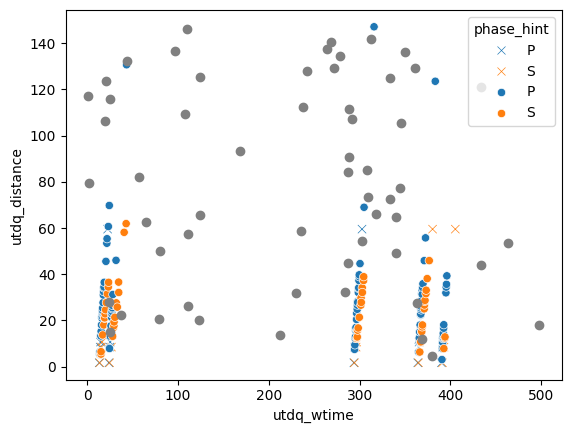

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import random

false = window[window["utdq_pick_type"]=="n"]
real_artificial = window[window["utdq_pick_type"]=="a"]
real_manual = window[window["utdq_pick_type"]=="o"]


fig,ax = plt.subplots()
ax.plot(false["utdq_wtime"], false["utdq_distance"], 'o',color="gray")
sns.scatterplot(data=real_artificial, x='utdq_wtime', y='utdq_distance', 
                hue='phase_hint', palette='tab10',
                marker="x",
                ax=ax)
sns.scatterplot(data=real_manual, x='utdq_wtime', y='utdq_distance', 
                hue='phase_hint', palette='tab10',ax=ax)
# ax.plot(window["utdq_wtime"], window["utdq_distance"], 'o',color="darkorange")
# plt.plot(window["utdq_wtime"], window["station"], 'o')
plt.show()

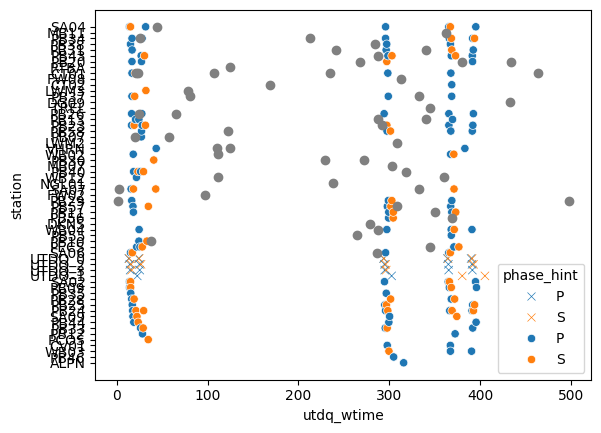

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig,ax = plt.subplots()
ax.plot(false["utdq_wtime"], false["station"], 'o',color="gray")
sns.scatterplot(data=real_artificial, x='utdq_wtime', y='station', 
                hue='phase_hint', palette='tab10',
                marker="x",
                ax=ax)
sns.scatterplot(data=real_manual, x='utdq_wtime', y='station', 
                hue='phase_hint', palette='tab10',ax=ax)
# ax.plot(window["utdq_wtime"], window["utdq_distance"], 'o',color="darkorange")
# plt.plot(window["utdq_wtime"], window["station"], 'o')
plt.show()

# save your windows in hsf format

In [45]:
window.to_hdf("window.h5",key="window_1",mode="w")

/tmp/ipykernel_56487/1952062211.py:1: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['ev_id', 'network', 'station', 'location', 'channel', 'phase_hint',
       'author', 'filter_id', 'method_id', 'polarity', 'evaluation_mode',
       'evaluation_status'],
      dtype='object')]

  window.to_hdf("window.h5",key="window_1",mode="w")


In [48]:
window_1 = pd.read_hdf("window.h5",key="window_1")
window_1

,ev_id,network,station,location,channel,phase_hint,time,time_lower_error,time_upper_error,author,...,time_weight,used,utdq_real,utdq_distance,utdq_azimuth,utdq_bazimuth,utdq_time,utdq_r2,utdq_r2_length,utdq_wtime
0,tx2024hrey,TX,PB13,01,HHN,P,2024-04-19 00:33:30.972988000,0.3,0.3,Anestis,...,0.805510,1.0,True,8.187932,26.293424,206.313396,1.889714,1.0,30.0,108.999162
1,tx2024hrey,4O,WB04,00,HHZ,P,2024-04-19 00:33:31.222610000,0.3,0.3,Anestis,...,1.040132,1.0,True,7.868136,306.822495,126.787834,2.139336,1.0,30.0,109.248784
0,tx2024hrey,UTDQ,UTDQ_2,NaN,NaN,P,2024-04-19 00:33:31.627937234,NaN,NaN,utdquake,...,NaN,NaN,True,8.603118,342.611891,162.611891,2.544663,1.0,30.0,109.654111
0,tx2024hrey,UTDQ,UTDQ_3,NaN,NaN,P,2024-04-19 00:33:31.745627751,NaN,NaN,utdquake,...,NaN,NaN,True,9.361952,34.405654,214.405654,2.662353,1.0,30.0,109.771801
0,tx2024hrey,UTDQ,UTDQ_0,NaN,NaN,P,2024-04-19 00:33:31.850228263,NaN,NaN,utdquake,...,NaN,NaN,True,10.036386,250.932861,70.932861,2.766954,1.0,30.0,109.876402
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,NaN,TX,PB01,NaN,NaN,P,NaT,NaN,NaN,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,75.665634
90,NaN,TX,PB31,NaN,NaN,S,NaT,NaN,NaN,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,169.746192
91,NaN,TX,PB33,NaN,NaN,S,NaT,NaN,NaN,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,203.084068
92,NaN,4O,SA07,NaN,NaN,S,NaT,NaN,NaN,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,455.335516


# IMportant

You will do this several tiem for several windows, varying different things, for example

- number of events (see the part catalog.sample) 
    - Note: you can use the query function before sampling, and then you should be able to select specific depths or magnitude, etc
- add_artificial picks (choice the number of stations, you can also variate the disance)
- remove_phases (the ratios)

in the window
- noise (number of picks with noise)


Save your results, remember to change window_q,window_2, ...etc